In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from p_tqdm import p_umap
import pandas as pd

In [2]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
plt.rcParams['axes.edgecolor'] = '0.0'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Sizes
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2.2

# Tick parameters
plt.rcParams['xtick.top'] = 'False'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.minor.visible'] = 'True'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.left'] = 'True'
plt.rcParams['ytick.right'] = 'False'
plt.rcParams['ytick.minor.visible'] = 'True'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['xtick.minor.size'] = 9/4
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['ytick.major.size'] = 3
plt.rcParams['ytick.minor.size'] = 9/4

In [5]:
from SFH_to_SNR_Iyer_tools import *
def load_h5(file_path):
    # Read all data into memory before parallelizing (h5py objects can't be pickled)
    with h5py.File(file_path, "r") as hf:
        print("Keys in HDF5 file:")
        for key in hf.keys():
            print(f" - {key}")

        data = []
        for CID in hf.keys():
            g = hf[CID]
            data.append((CID, g["sfh_samps"][:], g["lookback_times_gyr"][:]))

    return data

In [37]:
out_h5 = '2016A_sfh_chains.h5'
data = load_h5(out_h5)
list_of_CIDs, list_of_SN_samps = process_data(data)

Keys in HDF5 file:
 - 2016A


  0%|          | 0/1 [00:00<?, ?it/s]

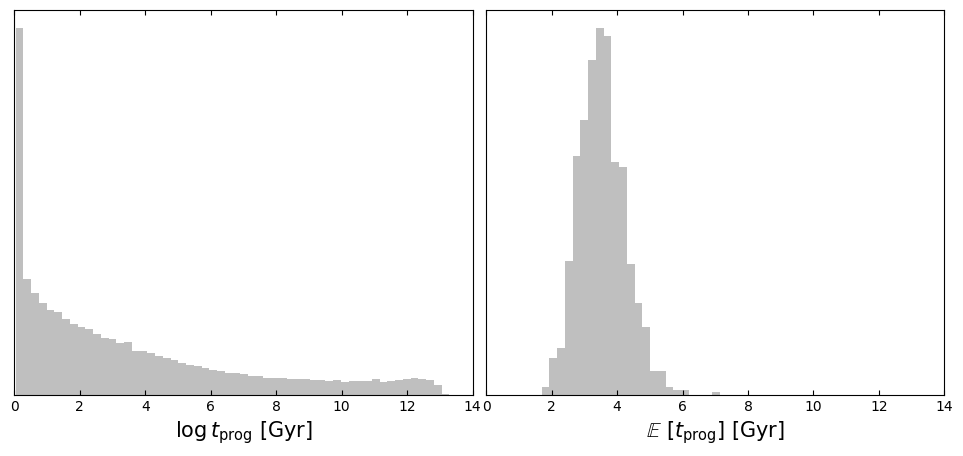

In [22]:
bins = np.linspace(0.04,14,60)

fig,axes = plt.subplots(1,2,figsize=(12,5))
plt.subplots_adjust(wspace=0.03)

# histograms
axes[0].hist(np.ravel(list_of_SN_samps), bins=bins, 
             density=True, alpha=0.5,
             color='gray');
axes[1].hist(np.ravel(np.mean(list_of_SN_samps, axis=2)), bins=bins, 
             density=True, alpha=0.5,
             color='gray');

# formatting
axes[0].set_xlabel(r"$\log t_{\mathrm{prog}}$ [Gyr]",fontsize=15)
axes[1].set_xlabel(r"$\mathbb{E}\ [t_{\mathrm{prog}}]$ [Gyr]",fontsize=15)  
for ax in axes:
    ax.set_yticks([])
    ax.tick_params(direction='in',top=True,right=True)
    ax.set_xlim(0,14)


# fig.suptitle(f"SN age distribution for {CID}", fontsize=16)

## plot sSFH

In [3]:
df_props = pd.read_csv('host_props.csv')
df_props

,transient,stellar_mass_16,stellar_mass_50,stellar_mass_84,sfr_16,sfr_50,sfr_84,ssfr_16,ssfr_50,ssfr_84,...,sdss_g_mag_84,sdss_r_mag_16,sdss_r_mag_50,sdss_r_mag_84,sdss_i_mag_16,sdss_i_mag_50,sdss_i_mag_84,sdss_z_mag_16,sdss_z_mag_50,sdss_z_mag_84
0,2019yvv,10.807717,10.845278,10.879808,1.273443,1.459392,1.624734,-10.734598,-10.685674,-10.632932,...,15.861011,15.166868,15.180109,15.194610,14.877508,14.890189,14.906278,14.662447,14.675906,14.691177
1,2023mhc,8.964541,9.040787,9.107953,0.357155,0.430188,0.517293,-9.536694,-9.407734,-9.259875,...,19.392320,18.730881,18.758883,18.782412,18.525101,18.544683,18.567971,18.336640,18.356081,18.380594
2,2018fpe,8.852427,8.913052,8.973787,0.010079,0.020472,0.035361,-10.901309,-10.606513,-10.361900,...,20.532010,20.048620,20.076163,20.103441,19.871230,19.902252,19.934244,19.777393,19.814503,19.847495
3,2020tzb,9.739091,9.787942,9.833200,0.500938,0.566818,0.648812,-10.114247,-10.033403,-9.955806,...,18.630074,18.116895,18.140943,18.163869,17.916487,17.937760,17.956280,17.698843,17.717440,17.735767
4,2024smo,9.693878,9.742260,9.789964,0.550787,0.607056,0.672661,-10.015427,-9.958161,-9.901649,...,17.543441,17.096672,17.117459,17.139191,16.955339,16.974735,16.992550,16.817641,16.836359,16.855309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9356,2020mtk,9.400307,9.434268,9.464950,0.212182,0.286109,0.366542,-10.090718,-9.974325,-9.880630,...,15.656251,15.289147,15.314937,15.343684,15.162976,15.193263,15.220314,15.043577,15.072640,15.096919
9357,2023hpw,10.999838,11.037038,11.065361,0.653758,0.873691,1.162938,-11.224804,-11.087828,-10.960814,...,15.858366,15.087341,15.101698,15.116422,14.740199,14.755284,14.769548,14.497009,14.512364,14.527958
9358,2020acai,10.761248,10.789404,10.824245,1.118325,1.262343,1.455696,-10.751685,-10.688230,-10.620254,...,13.951279,13.199926,13.215191,13.229572,12.867009,12.881363,12.896804,12.581108,12.594508,12.610287
9359,2017fwn,9.377198,9.434138,9.486251,0.129595,0.163941,0.199562,-10.323362,-10.228551,-10.129861,...,17.872958,17.321030,17.340674,17.359255,17.127617,17.147549,17.167441,16.996637,17.015908,17.035539


Keys in HDF5 file:
 - 2017hgz


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/sterling/miniconda3/envs/py312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_94048/1319141787.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(pdf_median, time_grid_Gyr)


Keys in HDF5 file:
 - 2019yyv


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/sterling/miniconda3/envs/py312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_94048/1319141787.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(pdf_median, time_grid_Gyr)


Keys in HDF5 file:
 - 2024vjb


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/sterling/miniconda3/envs/py312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_94048/1319141787.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(pdf_median, time_grid_Gyr)


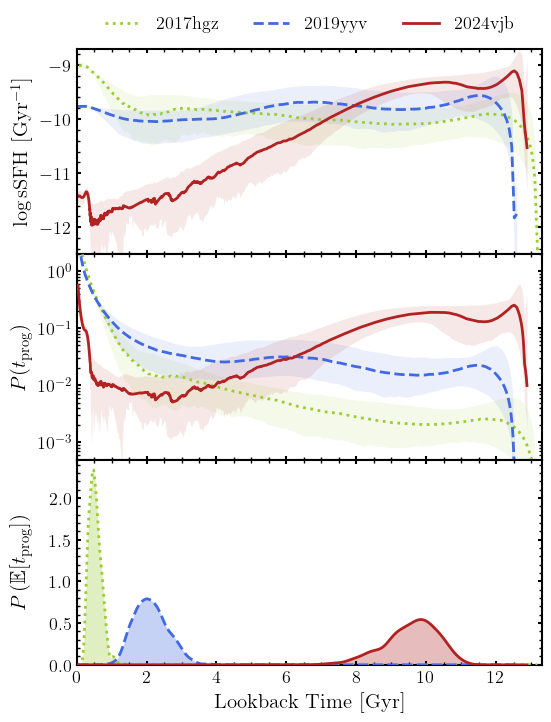

In [13]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(3,1,figsize=(6,8))
plt.subplots_adjust(hspace=0.)

colors = ['yellowgreen','royalblue','firebrick']
linestyles = [':','--','-']
for i,CID in enumerate(['2017hgz','2019yyv','2024vjb']):
    
    # load data
    out_h5 = f'{CID}_sfh_chains.h5'
    data = load_h5(out_h5)
    list_of_CIDs, list_of_SN_samps = process_data(data)
    data_CID = [data[i][0] for i in range(len(data))]
    data_SFH_samps = [data[i][1] for i in range(len(data))]
    data_lookback_times = [data[i][2] for i in range(len(data))]

    # compute sSFH
    logmass = df_props[df_props['transient'] == CID]['stellar_mass_50'].values[0]
    idx = data_CID.index(CID)
    SFH_samps = data_SFH_samps[idx]
    _SFH_samps_nonzero = SFH_samps.copy()
    _SFH_samps_nonzero[_SFH_samps_nonzero==0.] = np.nan
    sSFH_samps = np.log10(_SFH_samps_nonzero) - logmass
    lookback_times = data_lookback_times[idx]

    # get sSFH percentiles
    sSFH_lower, sSFH_median, sSFH_upper = np.nanpercentile(sSFH_samps, [16, 50, 84], axis=0)

    # get SN age pdf
    tmax = lookback_times[np.isfinite(sSFH_median)].max()
    _s = np.isfinite(sSFH_median)
    time_grid_Gyr = np.arange(0.04, tmax, 0.01)
    pdf_lower,pdf_median,pdf_upper = [
        SFH_to_SN_age_PDF(
            10**ssfh[_s], lookback_times[_s],
            time_grid_Gyr=time_grid_Gyr,
            normalize=False
        )
        for ssfh in [sSFH_lower, sSFH_median, sSFH_upper]
    ]
    norm = np.trapz(pdf_median, time_grid_Gyr)
    pdf_lower /= norm
    pdf_median /= norm
    pdf_upper /= norm
    
    axes[0].fill_between(lookback_times, sSFH_lower, sSFH_upper, 
                    color=colors[i], alpha=0.1, lw=0)
    axes[0].plot(lookback_times, sSFH_median, color=colors[i], 
            ls=linestyles[i], lw=2, label=CID)

    axes[1].plot(time_grid_Gyr, pdf_median, color=colors[i],
                 ls=linestyles[i], lw=2, zorder=10)
    axes[1].fill_between(time_grid_Gyr, pdf_lower, pdf_upper, 
                         color=colors[i], alpha=0.1, lw=0)

    # get samples
    sampled_ages = helper(SFH_samps, lookback_times)
    _E_samples = np.ravel(np.mean(sampled_ages, axis=1))
    _kde = gaussian_kde(_E_samples)
    axes[2].plot(time_grid_Gyr, _kde(time_grid_Gyr), 
                 ls=linestyles[i], lw=2, color=colors[i], zorder=10)
    axes[2].fill_between(time_grid_Gyr, 0,_kde(time_grid_Gyr), 
                         lw=0, color=colors[i], alpha=0.3)
    
axes[0].set_ylabel(r'$\log \mathrm{sSFH}$ [Gyr$^{-1}$]', fontsize=15)
axes[0].set_xlim(0,13.3)
axes[0].set_ylim(-12.5,-8.7)

axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(5e-4,2)
axes[1].set_yscale('log')
axes[1].set_ylabel(r'$P(t_\mathrm{prog})$', fontsize=15)
    
axes[2].set_ylim(0,)
axes[2].set_ylabel(r'$P\left(\mathbb{E}[t_\mathrm{prog}]\right)$', fontsize=15)
axes[2].set_xlim(axes[0].get_xlim())
# axes[2].set_yticks([])
    
for ax in axes:
    ax.tick_params(direction='in',which='both',top=True,right=True)

fig.align_ylabels(axes)
axes[0].set_xticklabels([])
axes[1].set_xticklabels([])
axes[2].set_xlabel('Lookback Time [Gyr]', fontsize=15)
axes[0].legend(loc='lower center',ncol=3,bbox_to_anchor=(0.5,1.0),frameon=False)
plt.savefig('figures/SFH_to_t_prog.pdf', bbox_inches='tight')